In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('../__datasets__/titanic_toy.csv')
df.sample(3)

,Age,Fare,Family,Survived
51,21.0,7.80,0,0
783,NaN,23.45,3,0
372,19.0,8.05,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [6]:
df.isna().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [12]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [19]:
X_train.isnull().mean()*100

Age       19.662921
Fare       5.056180
Family     0.000000
dtype: float64

In [20]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [22]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)

In [23]:
X_train.sample(3)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
774,54.0,23.00,4,54.0,54.000000,23.00,23.00
0,22.0,7.25,1,22.0,22.000000,7.25,7.25
760,NaN,14.50,0,28.0,29.498846,14.50,14.50


In [26]:
print('Original Age Variable variance : ', X_train['Age'].var())

print(' Age Variance after median imputation : ', X_train['Age_median'].var())
print(' Age Variance after mean imputation : ', X_train['Age_mean'].var())

print('Original Fare Variable variance : ', X_train['Fare'].var())

print(' Fare Variance after median imputation : ', X_train['Fare_median'].var())
print(' Fare Variance after mean imputation : ', X_train['Fare_mean'].var())

Original Age Variable variance :  210.2517072477438
 Age Variance after median imputation :  169.20731007048096
 Age Variance after mean imputation :  168.8519336687225
Original Fare Variable variance :  2761.031434948639
 Fare Variance after median imputation :  2637.01248167777
 Fare Variance after mean imputation :  2621.2323749512393


In [28]:
print(X_train['Age_mean'].var(), X_train['Age'].var())

168.8519336687225 210.2517072477438


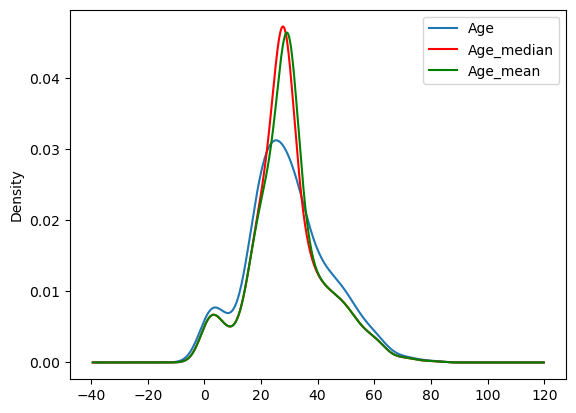

In [33]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# Variable imputed with median
X_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# Variable imputed with mean
X_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

line, labels = ax.get_legend_handles_labels()
ax.legend(line, labels, loc='best')

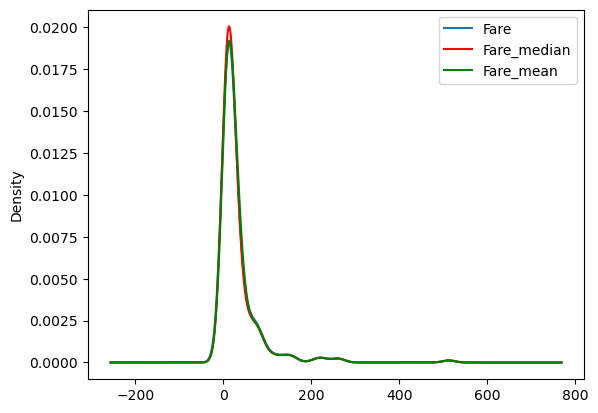

In [34]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original variable distribution
X_train['Fare'].plot(kind='kde', ax=ax)

# Variable imputed with median
X_train['Fare_median'].plot(kind='kde', ax=ax, color='red')

# Variable imputed with mean
X_train['Fare_mean'].plot(kind='kde', ax=ax, color='green')

line, labels = ax.get_legend_handles_labels()
ax.legend(line, labels, loc='best')

In [35]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,70.082085,71.193767
Fare,75.481375,2761.031435,18.599163,63.938058,60.224654,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.587710,-5.616299,17.672035,17.657433
Age_median,210.251707,63.938058,-5.587710,169.207310,168.851934,59.728510,60.700688
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,56.282518,57.175304
Fare_median,70.082085,2761.031435,17.672035,59.728510,56.282518,2637.012482,2621.232375
Fare_mean,71.193767,2761.031435,17.657433,60.700688,57.175304,2621.232375,2621.232375


In [36]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.087232,0.088944
Fare,0.091482,1.000000,0.207193,0.093496,0.088151,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.255307,-0.256883,0.204536,0.204981
Age_median,1.000000,0.093496,-0.255307,1.000000,0.998949,0.089416,0.091145
Age_mean,1.000000,0.088151,-0.256883,0.998949,1.000000,0.084346,0.085941
Fare_median,0.087232,1.000000,0.204536,0.089416,0.084346,1.000000,0.997003
Fare_mean,0.088944,1.000000,0.204981,0.091145,0.085941,0.997003,1.000000


<Axes: >

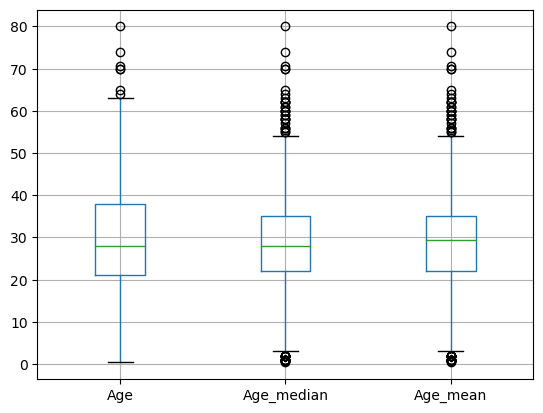

In [37]:
X_train[['Age', 'Age_median', 'Age_mean']].boxplot()

<Axes: >

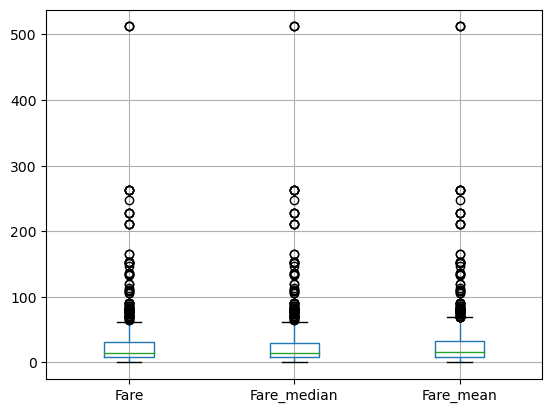

In [38]:
X_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

## Using sklearn to do all same work

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
imputer1 = SimpleImputer(strategy='median')   # default strategy='mean'
imputer2 = SimpleImputer(strategy='mean')

In [41]:
trf = ColumnTransformer([
    ('imputer1', imputer1, ['Age']),
    ('imputer2', imputer2, ['Fare'])
], remainder='passthrough')

In [42]:
trf.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [43]:
trf.named_transformers_['imputer1'].statistics_

array([28.])

In [44]:
trf.named_transformers_['imputer2'].statistics_

array([32.51778772])

In [45]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [46]:
X_train

array([[ 45.5       ,  28.5       ,   0.        ],
       [ 23.        ,  13.        ,   0.        ],
       [ 32.        ,   7.925     ,   0.        ],
       ...,
       [ 41.        ,  32.51778772,   2.        ],
       [ 14.        , 120.        ,   3.        ],
       [ 21.        ,  77.2875    ,   1.        ]])